### Test migration history reconstruction on breast cancer data


In [1]:
import sys
import os

repo_dir = os.path.join(os.getcwd(), "metient")

from metient.util.globals import *
from metient.metient import *
from metient.util import pairtree_data_extraction_util as ptutil
from metient.util import data_extraction_util as dutil

import matplotlib
import torch
import pandas as pd

matplotlib.rcParams['figure.figsize'] = [3, 3]
custom_colors = ["#6aa84f","#c27ba0", "#be5742e1", "#6fa8dc", "#e69138", "#9e9e9e"]
HOADLEY_DATA_DIR = os.path.join(repo_dir, 'data/hoadley_breast_cancer_2016')
MSK_MET_FN = os.path.join(repo_dir, 'data/msk_met/msk_met_freq_by_cancer_type.csv')
OUTPUT_DIR = os.path.join(repo_dir, 'data', 'hoadley_breast_cancer_2016')

In [2]:
HOAD_MSK_MET_MAP = {
    "liver": "Liver",
    "brain": "CNS/Brain",
    "rib": "Bone",
    "breast": "Breast",
    "kidney": "Kidney",
    "lung": "Lung",
    "adrenal": "Adrenal Gland",
    "spinal": "CNS/Brain"
}

print_config = PrintConfig(visualize=True, verbose=True, k_best_trees=20, custom_colors=custom_colors)

def run_evaluate(patient_id, custom_colors, weights, run_name):
    mut_trees_fn = os.path.join(HOADLEY_DATA_DIR, "orchard_trees", f"{patient_id}.results.npz")
    ref_var_fn = os.path.join(HOADLEY_DATA_DIR, "pyclone_clustered_tsvs", f"{patient_id}_SNVs.tsv")
    df = pd.read_csv(ref_var_fn, delimiter="\t")
    sorted_tuples = sorted(zip(df['anatomical_site_index'].unique(), df['anatomical_site_label'].unique()))
    unique_sites = [t[1] for t in sorted_tuples]
    trees = ptutil.get_adj_matrices_from_pairtree_results(mut_trees_fn)
    print("num trees:", len(trees))
    print(unique_sites)
    tree_num = 1
    for adj_matrix in trees:
        print(f"\nTREE {tree_num}")
        O = dutil.get_organotropism_matrix_from_msk_met(unique_sites, "Breast Cancer", MSK_MET_FN, HOAD_MSK_MET_MAP)
        print("organotropism",O)
        if weights.organotrop == 0.0: O = None
        
        evaluate(adj_matrix, ref_var_fn, weights, print_config, OUTPUT_DIR, f"{run_name}_tree{tree_num}",
                 O=O,  solve_polytomies=True)
        tree_num += 1



### Initialize two sets of weights, one with max. pars. + gen dist, one with max. pars + gen. dist. + organotrop

In [3]:
# Use default maximum parsimony weights
weights = Weights(gen_dist=0.1, organotrop=0.0)
organo_weights = Weights(gen_dist=0.1, organotrop=0.1)


### Patient A1, maximum parsimony + gen. dist. objective

num trees: 2
['breast', 'adrenal', 'liver', 'lung', 'spinal']

TREE 1
organotropism tensor([0.02, 0.01, 0.12, 0.08, 0.06])
/lila/data/morrisq/divyak/projects/metient/metient/data/hoadley_breast_cancer_2016/tmp_A1_eval_gd_tree1_clustered_SNVs.tsv
ordered_sites ['breast', 'adrenal', 'liver', 'lung', 'spinal']
input T shape: torch.Size([10, 10])
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 1., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
node indices not well estimated []
full_T torch.Size([27, 27])


  0%|          | 0/1000 [00:00<?, ?it/s]/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
 10%|▉         | 95/1000 [00:02<00:17, 51.67it/s]/lila/data/morrisq/divyak/projects/metient/metient/util/optimal_subtrees.py:216: UserWarning: The use of `x.T` on tensors of di

Time elapsed: 32.002086
weights being used 0.48 0.3 0.22
all_pars_metrics [(12, 5, 2), (14, 9, 3), (14, 6, 2), (13, 6, 3), (13, 6, 2), (12, 6, 2), (15, 9, 3), (14, 7, 2), (14, 10, 3), (13, 7, 3), (17, 11, 3), (13, 7, 3), (12, 7, 3), (13, 7, 2), (13, 7, 3), (14, 8, 3), (12, 5, 2), (15, 8, 2), (14, 9, 3), (14, 7, 3), (13, 7, 3), (14, 10, 3), (16, 10, 3), (12, 7, 3), (13, 6, 2), (13, 7, 3), (14, 7, 2), (13, 8, 3), (15, 8, 2), (14, 10, 3), (13, 7, 2), (12, 4, 1), (14, 8, 3), (14, 8, 3), (15, 9, 3), (14, 10, 3), (14, 9, 3), (13, 7, 2), (14, 7, 2), (14, 8, 3), (13, 9, 3), (11, 7, 3), (13, 9, 3), (12, 7, 3), (14, 7, 2), (14, 10, 3), (12, 8, 2), (15, 10, 3), (14, 8, 2), (14, 8, 3), (16, 7, 2), (16, 9, 2), (13, 9, 3), (15, 8, 2), (13, 8, 3), (14, 7, 3), (11, 5, 2), (12, 5, 2), (15, 7, 3), (15, 8, 3), (15, 8, 3), (14, 8, 3), (14, 11, 3), (14, 10, 3), (14, 9, 3), (14, 7, 3), (14, 11, 3), (15, 9, 2), (13, 8, 2), (13, 9, 3), (13, 9, 3), (12, 8, 3), (12, 7, 3), (13, 8, 3), (12, 7, 3), (12, 8, 3), (1

<Figure size 300x300 with 0 Axes>

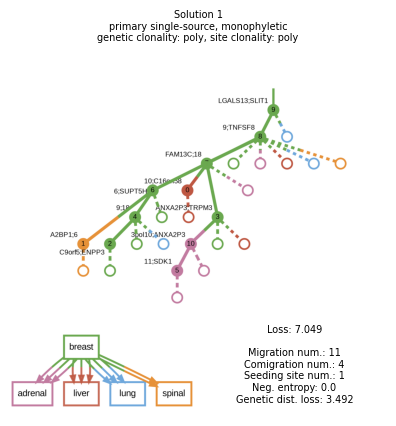

Saving A1_eval_gd_tree1_breast to /lila/data/morrisq/divyak/projects/metient/metient/data/hoadley_breast_cancer_2016

TREE 2
organotropism tensor([0.02, 0.01, 0.12, 0.08, 0.06])
/lila/data/morrisq/divyak/projects/metient/metient/data/hoadley_breast_cancer_2016/tmp_A1_eval_gd_tree2_clustered_SNVs.tsv
ordered_sites ['breast', 'adrenal', 'liver', 'lung', 'spinal']
input T shape: torch.Size([10, 10])
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
node indices not well estimated []
full_T torch.Size([27, 27])


100%|██████████| 1000/1000 [00:43<00:00, 22.81it/s]
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
100%|██████████| 1000/1000 [00:23<00:00, 22.41it/s]

Time elapsed: 24.374078
weights being used 0.48 0.3 0.22
all_pars_metrics [(11, 7, 2), (12, 5, 2), (15, 8, 3), (14, 8, 2), (13, 6, 2), (14, 9, 3), (14, 8, 3), (13, 10, 2), (13, 7, 3), (13, 6, 2), (14, 7, 2), (12, 7, 2), (13, 8, 2), (15, 7, 3), (14, 6, 3), (15, 6, 3), (14, 6, 2), (13, 8, 3), (13, 7, 2), (13, 9, 3), (14, 10, 2), (13, 7, 3), (14, 7, 2), (15, 10, 3), (15, 9, 3), (14, 7, 3), (13, 7, 2), (15, 10, 3), (16, 10, 3), (14, 8, 3), (12, 7, 2), (13, 7, 3), (16, 7, 3), (14, 7, 3), (14, 8, 3), (14, 8, 3), (12, 7, 3), (11, 6, 2), (14, 9, 3), (14, 8, 3), (13, 8, 3), (14, 7, 3), (12, 8, 3), (14, 6, 3), (13, 8, 2), (14, 6, 3), (13, 6, 2), (13, 10, 3), (16, 8, 3), (12, 6, 2), (14, 9, 3), (11, 7, 2), (12, 7, 2), (12, 7, 3), (16, 10, 3), (15, 8, 3), (15, 8, 2), (12, 6, 3), (13, 5, 2), (15, 8, 3), (13, 9, 3), (14, 6, 3), (15, 7, 3), (13, 6, 3), (15, 9, 2), (13, 7, 3), (13, 7, 3), (14, 8, 3), (15, 9, 2), (17, 8, 3), (13, 8, 3), (13, 6, 2), (13, 8, 3), (14, 11, 3), (13, 5, 2), (14, 9, 3), (11, 

<Figure size 300x300 with 0 Axes>

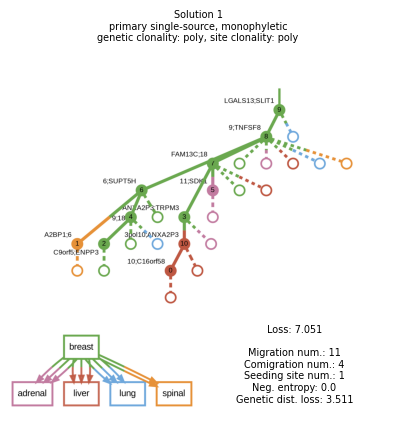

Saving A1_eval_gd_tree2_breast to /lila/data/morrisq/divyak/projects/metient/metient/data/hoadley_breast_cancer_2016
 

         23540257 function calls (21008041 primitive calls) in 81.343 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     2600    9.555    0.004    9.555    0.004 {method 'run_backward' of 'torch._C._EngineBase' objects}
     4213    5.458    0.001   11.687    0.003 vertex_labeling_util.py:1342(purdom_transitive_closure)
     1795    4.380    0.002   17.258    0.010 vertex_labeling_util.py:245(comigration_number)
     9124    4.319    0.000    4.319    0.000 {built-in method torch.isin}
   143788    4.129    0.000    4.129    0.000 {method 'unbind' of 'torch._C._TensorBase' objects}
    54640    4.000    0.000    4.000    0.000 {method 'coalesce' of 'torch._C._TensorBase' objects}
     4028    2.646    0.001    2.646    0.001 {built-in method torch.rand}
     3781    2.292    0.001    2.292    0.001 {built-in method torch.bmm}
2383599/1797    1.896    0.000    4.406    0.002 copy.py:128(deepcopy)
     2472    1.596    0.00

100%|██████████| 1000/1000 [00:36<00:00, 22.41it/s]

In [4]:
%%prun
run_evaluate("A1", custom_colors, weights, "A1_eval_gd")

### Patient A1, maximum parsimony + gen. dist. + organotropism objective

In [5]:
run_evaluate("A1", custom_colors, organo_weights, "A1_eval_gd_organo")

### Patient A7, evaluate mode, maximum parsimony + gen. dist. objective

In [6]:
run_evaluate("A7", custom_colors, weights, "A7_eval_gd")

### Patient A7, evaluate mode, maximum parsimony + gen. dist. + organotropism objective

In [ ]:
run_evaluate("A7", custom_colors, organo_weights, "A7_eval_gd_organo")